<a id="top"></a>
# Accessing Roman Catalogs: Leveraging Ancillary Tables and Visualization to Apply Data Quality Cuts
***


## Learning Goals
By the end of this tutorial, you will:

- Understand how to launch and programatically control [MAST Aladin](https://mast-aladin.readthedocs.io/en/latest/index.html) to view targets on the sky from within a notebook, including overlaying a set of targets and observation footprints on the sky.
- Understand how to use the [MAST catalog schema browser](https://mast.stsci.edu/schema_browser/#/) to discover ancillary tables.
- Understand how to "decode" catalog bitflags, aided by a bitflag "helper" class and the bitflag definition documentation (or database flag definition tables).


## Table of Contents

* [Introduction](#introduction)
* [Imports](#imports)
* [Identification and quality checks on candidate stars in the Galactic Bulge](#identification-and-quality-checks-on-candidate-stars-in-the-galactic-bulge)
   * [Identifying candidate stars in the Galactic Bulge](#identifying-candidate-stars-in-the-galactic-bulge)
   * [Launching MAST-Aladin to inspect targets & outliers](#launching-mast-aladin-to-inspect-targets-&-outliers)
   * [Examining quality flag information](#examining-quality-flag-information)
   * [Refining the sample with data quality cuts](#refining-the-sample-with-data-quality-cuts)
* [Additional Resources](#additional-resources)
* [Citations](#citations)
* [About This Notebook](#about-this-notebook)

## Introduction

This notebook demonstrates how to leverage catalog queries together with [MAST Aladin](https://mast-aladin.readthedocs.io/en/latest/index.html) (to view objects on the sky) and the [MAST Catalog Schema Browser](https://mast.stsci.edu/schema_browser/#/) to examine a selected sample, investigate data quality issues, and identify quality flags that can be used to refine the sample for analysis.

MAST will provide access to a range of Roman catalog products. In addition to analysis-ready measurements of observed and derived physical quantities, Roman catalogs will include ancillary information about, e.g., data quality, processing flags, and data provenance (such as the primary/overlap designation bit flag in the `flagged_spatial_id` identifiers in [WFI multiband photometric source catalogs](https://roman-docs.stsci.edu/data-handbook/wfi-data-levels-and-products#WFIDataLevelsandProducts-Level4)). This notebook demonstrates how to query candidate stars in the Galactic Bulge using multiband photometry, view the targets in MAST Aladin, and then examine data quality flag information from ancillary tables/columns to determine how to exclude data artifacts and spurious sources from the analysis.

## Imports

This tutorial makes use of the following packages: 
- [*astroquery.mast Catalogs, Observations*](https://astroquery.readthedocs.io/en/latest/mast/mast.html) for querying the MAST catalog database and observation holdings
- [*astropy.coordinates SkyCoord*](https://docs.astropy.org/en/stable/coordinates/index.html) for defining sky coordinates
- [*astropy.units*](https://docs.astropy.org/en/stable/units/index.html) to specify angular units
- [*numpy*](https://numpy.org/doc/stable/) for numerical calculations
- [*matplotlib.pyplot*](https://matplotlib.org/stable/) for plotting catalog data
- [*mast_aladin*](github.com/spacetelescope/mast-aladin) to view targets on the sky
- [*sidecar Sidecar*](https://github.com/jupyter-widgets/jupyterlab-sidecar) to display MAST-Aladin alongside the notebook
- *time* to enable time delays when flipping through objects with MAST-Aladin
- [*astropy.table Table*](https://docs.astropy.org/en/stable/table/index.html) to construct tables from flag values
- A simple "flag helper class" *PanSTARRSFlagHelper* to retrieve definitions (from a table via a [MAST TAP service](http://mast.stsci.edu/vo-tap/)), represent, and help parse data quality flags encoded as bitflags for easier readibility.

In [1]:
from astroquery.mast import Catalogs, Observations
from astropy.coordinates import SkyCoord
from astropy.table import Table
import astropy.units as u
import numpy as np

from mast_aladin import MastAladin
from sidecar import Sidecar
import matplotlib.pyplot as plt
from flag_helper import PanSTARRSFlagHelper
import time

************

## Identification and quality checks on candidate stars in the Galactic Bulge

In this notebook, we will construct a color-magnitude diagram ($r-i$ vs $z$) of stars in the Milky Way bulge near the Galactic Center, from which specific categories of stars can be selected for further analysis.


For demonstration purposes (as Roman catalogs are not yet available), PanSTARRS will be used as the example dataset. Similar to Roman (particularly the WFI [multiband photometric source catalogs](https://roman-docs.stsci.edu/data-handbook/wfi-data-levels-and-products#WFIDataLevelsandProducts-Level4)),  PanSTARRS features a rich set of ancillary tables containing data quality and processing flags — providing a reasonable analog to demonstrate MAST data access and visualization tools that will be available for use with Roman.


(In the interest of simplicity, this example will omit crossmatching to Gaia to leverage Gaia-derived distances to exclude fore/background objects.)

### Identifying candidate stars in the Galactic Bulge

In this example, we aim to identify stars in the Galactic Bulge by constructing a $r-i$ vs $z$ color magnitude diagram. We begin with the following selection criteria:
* Located within 0.1 degree of the Galactic center
* Are point sources (excluding extended objects, such as galaxies).
* Have measured $r$, $i$, $z$ magnitudes 


#### Querying the PanSTARRS catalog

First, we consult the [PanSTARRS DR2 catalogs documentation](https://outerspace.stsci.edu/spaces/PANSTARRS/pages/298812351/PS1+Source+extraction+and+catalogs) and the MAST Catalog Schema Browser](https://mast.stsci.edu/schema_browser/#/ps1_dr2/mean_object) to investigate the available tables and columns.

We determine that we can obtain all necessary information from the PanSTARRS DR2 "mean" table, which we can access using [`astroquery.mast`](https://astroquery.readthedocs.io/en/latest/mast/mast_catalog.html).

To construct our query, we begin by obtaining the sky coordinates for the Galactic center using astropy.

In [2]:
# Use the Astropy SkyCoord name resolver to get 
# the position of the galactic center in the ICRS frame
gc = SkyCoord.from_name("Galactic center")
gc

<SkyCoord (ICRS): (ra, dec) in deg
    (266.41500889, -29.00611111)>

Based on PanSTARRS documentation (from [`astroquery.mast`](https://catalogs.mast.stsci.edu/docs/panstarrs.html) and the [PanSTARRS DR2 documentation](https://outerspace.stsci.edu/spaces/PANSTARRS/pages/298812351/PS1+Source+extraction+and+catalogs)), we see the `MeanObject` catalog provides the relevant photometric information (in the columns `rMeanPSFMag`, `iMeanPSFMag`, `zMeanPSFMag`), as well as position information (RA/Dec).

Using the `Catalogs` module of `astroquery.mast`, 
we query the PanSTARRS `mean_object` table to perform a cone search of 0.1 degree around the Galactic Center, restricting the results to objcts with $r$, $i$, $z$ magnitudes > -999 (the placeholder used for [missing values in the database](https://outerspace.stsci.edu/display/PANSTARRS/PS1+MeanObject+table+fields)). 

In [3]:
# Query the PanSTARRS DR2 Mean catalog aroung the 
# Galactic center, with available z,r,i magnitudes
sample = Catalogs.query_criteria(
    collection="ps1_dr2",
    catalog="mean_object",
    coordinates=gc,
    radius=0.1*u.deg,
    rMeanPSFMag=">-999",   # missing magnitudes are -999
    iMeanPSFMag=">-999",   # missing magnitudes are -999
    zMeanPSFMag=">-999",   # missing magnitudes are -999
)

*(Note: the returned table column names are all lower case, which we use below.)*

Next, to distinguish stars (point sources) from extended objects, we will make a cut using the PSF and Kron magnitudes in the `i` band, as point sources typically have `iMeanPSFMag-iMeanKronMag <= 0.05` (as recommended [in the PanSTARRS documentation](https://outerspace.stsci.edu/display/PANSTARRS/How+to+separate+stars+and+galaxies)).

In [4]:
sample = sample[
    sample['imeanpsfmag']-sample['imeankronmag'] <= 0.05
]

Finally, we will sort our sample by descending "objID" for consistent ordering.

In [5]:
sample.sort("objid", reverse=True)

Our resulting sample has 2906 candidate stars:

In [6]:
sample

objname,objaltname1,objaltname2,objaltname3,objid,uniquepspsobid,ippobjid,surveyid,htmid,zoneid,tessid,projectionid,skycellid,randomid,batchid,dvoregionid,processingversion,objinfoflag,qualityflag,rastack,decstack,rastackerr,decstackerr,rameanerr,decmeanerr,epochmean,posmeanchisq,cx,cy,cz,lambda,beta,l,b,nstackobjectrows,nstackdetections,ndetections,ng,nr,ni,nz,ny,gqfperfect,gmeanpsfmag,gmeanpsfmagerr,gmeanpsfmagstd,gmeanpsfmagnpt,gmeanpsfmagmin,gmeanpsfmagmax,gmeankronmag,gmeankronmagerr,gmeankronmagstd,gmeankronmagnpt,gmeanapmag,gmeanapmagerr,gmeanapmagstd,gmeanapmagnpt,gflags,rqfperfect,rmeanpsfmag,rmeanpsfmagerr,rmeanpsfmagstd,rmeanpsfmagnpt,rmeanpsfmagmin,rmeanpsfmagmax,rmeankronmag,rmeankronmagerr,rmeankronmagstd,rmeankronmagnpt,rmeanapmag,rmeanapmagerr,rmeanapmagstd,rmeanapmagnpt,rflags,iqfperfect,imeanpsfmag,imeanpsfmagerr,imeanpsfmagstd,imeanpsfmagnpt,imeanpsfmagmin,imeanpsfmagmax,imeankronmag,imeankronmagerr,imeankronmagstd,imeankronmagnpt,imeanapmag,imeanapmagerr,imeanapmagstd,imeanapmagnpt,iflags,zqfperfect,zmeanpsfmag,zmeanpsfmagerr,zmeanpsfmagstd,zmeanpsfmagnpt,zmeanpsfmagmin,zmeanpsfmagmax,zmeankronmag,zmeankronmagerr,zmeankronmagstd,zmeankronmagnpt,zmeanapmag,zmeanapmagerr,zmeanapmagstd,zmeanapmagnpt,zflags,yqfperfect,ymeanpsfmag,ymeanpsfmagerr,ymeanpsfmagstd,ymeanpsfmagnpt,ymeanpsfmagmin,ymeanpsfmagmax,ymeankronmag,ymeankronmagerr,ymeankronmagstd,ymeankronmagnpt,ymeanapmag,ymeanapmagerr,ymeanapmagstd,ymeanapmagnpt,yflags,astrometrycorrectionflag,pmra,pmdec,pmraerr,pmdecerr,decmean,ramean
,,,,,,,,,,,,,,,,,,,deg,deg,mas,mas,mas,mas,d,,,,,deg,deg,deg,deg,,,,,,,,,,mag,mag,mag,,mag,mag,mag,mag,mag,,mag,mag,mag,,,,mag,mag,mag,,mag,mag,mag,mag,mag,,mag,mag,mag,,,,mag,mag,mag,,mag,mag,mag,mag,mag,,mag,mag,mag,,,,mag,mag,mag,,mag,mag,mag,mag,mag,,mag,mag,mag,,,,mag,mag,mag,,mag,mag,mag,mag,mag,,mag,mag,mag,,,,mas,mas,mas,mas,deg,deg
object,object,object,object,int64,int64,int64,uint8,int64,int32,uint8,int16,uint8,float64,int64,int32,uint8,int32,uint8,float64,float64,float32,float32,float32,float32,float64,float32,float64,float64,float64,float64,float64,float64,float64,int16,int16,int16,int16,int16,int16,int16,int16,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,int16,float32,float32,float32,int16,int32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,int16,float32,float32,float32,int16,int32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,int16,float32,float32,float32,int16,int32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,int16,float32,float32,float32,int16,int32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,int16,float32,float32,float32,int16,int32,uint8,float32,float32,float32,float32,float64,float64
PSO J266.4148-28.9061,-999,-999,-999,73312664147912990,3526718000013439,511109698172032,0,11710823714680,7331,1,693,70,0.764368522692815,3526718,119002,3,436527104,52,266.41478676,-28.90610598,0.001,0.001,0.0070586307,0.0070586307,55927.67218421359,2.977626,-0.05474229746111264,-0.8736995987831238,-0.48337593232895626,266.847371042176,-5.506067272511191,0.03010305808887179,0.00834130681494409,-999,5,43,0,8,10,13,12,-999.0,-999.0,-999.0,-999.0,0,-999.0,-999.0,-999.0,-999.0,-999.0,0,-999.0,-999.0,-999.0,0,114720,0.998891,21.3498,0.061316,0.219186,5,21.2942,21.7458,21.3105,0.105665,0.609897,4,21.2082,0.080092,0.766996,5,115000,0.999104,19.8697,0.072825,0.111847,4,19.8166,19.9951,19.965,0.095545,0.159543,4,19.8827,0.103618,0.178087,4,115000,0.998817,19.1733,0.022056,0.194126,7,19.1342,19.6215,19.3604,0.065533,0.351007,6,19.227,0.037813,0.12218,6,114992,0.998956,18.9296,0.039735,0.120504,7,18.7681,19.0617,19.7013,0.31707,0.589191,6,19.7993,0.01751,0.336853,7,115000,7,-5.892208,-21.073942,5.3919663,5.3919663,-28.90612260697708,266.4147770200182
PSO J266.4113-28.9084,-999,-999,-999,73312664113250267,3526718000012839,511109698171432,0,11710823704335,7331,1,693,70,0.489421554

#### Visualizing the candidate stars

Next, we plot a preliminary $r-i$ vs $z$ color-magnitude diagram of our candidate stars in the Galactic Bulge.

(22.22845063209534, 7.958129072189331)

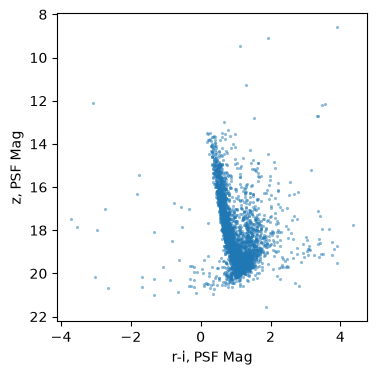

In [7]:
f, ax = plt.subplots()
f.set_size_inches((4, 4))
ax.scatter(
    sample['rmeanpsfmag']-sample['imeanpsfmag'],
    sample['zmeanpsfmag'], 
    s=5, lw=0, 
    alpha=0.5
)

ax.set_xlabel("r-i, PSF Mag")
ax.set_ylabel("z, PSF Mag")

# Invert y axis limits to plot fainter -> brighter
ax.set_ylim(ax.get_ylim()[::-1])

We see a lot of objects in our preliminary sample that are surprisingly red or blue in $r-i$. This suggests there may be data quality cuts that need to be made for our final sample.

To investigate, we first define a color cut to roughly select these very blue or red candidates, where objects with $r-i > 3$ or $<0$ are flagged as potentially suspect (overplotted in red below).

(22.22845063209534, 7.958129072189331)

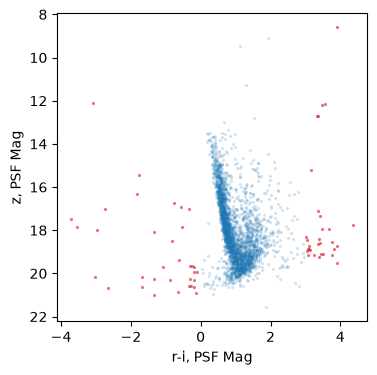

In [8]:
f, ax = plt.subplots()
f.set_size_inches((4, 4))

# Plot full preliminary sample
ax.scatter(
    sample['rmeanpsfmag']-sample['imeanpsfmag'],
    sample['zmeanpsfmag'], 
    s=5, lw=0, 
    alpha=0.2
)

# Rough suspect target color cut
whsuspect = (
    (sample['rmeanpsfmag']-sample['imeanpsfmag'] > 3)
) | (
    (sample['rmeanpsfmag']-sample['imeanpsfmag'] < 0)
) 

# Overplot potentially suspect targets
ax.scatter(
    (sample['rmeanpsfmag']-sample['imeanpsfmag'])[whsuspect],
    sample['zmeanpsfmag'][whsuspect], 
    s=5, lw=0, 
    alpha=0.5,
    color='red'
)


ax.set_xlabel("r-i, PSF Mag")
ax.set_ylabel("z, PSF Mag")

ax.set_ylim(ax.get_ylim()[::-1])

Overall, this selection includes 65 (potentially) suspect objects.

In [9]:
len(sample[whsuspect])

65

-----

### Launching MAST-Aladin to inspect targets & outliers

We'll now launch MAST-Aladin to the side of our notebook, to visually examine these suspect targets over a sky map of PanSTARRS imaging to hunt for clues regarding what type of quality issues might be at play with these very red/blue objects.

In [10]:
# Launch MAST-Aladin
with Sidecar(title="Aladin Viewer", anchor="split-right"):
    mast_aladin = MastAladin()
    display(mast_aladin)

As we're working with PanSTARRS data in the galactic bulge, we will also change the base survey imaging to the PanSTARRS1 imaging, and center the viewport at the center of the GBTDS imaging (with a 5 degree field of view).

(See the documentation for [ipyaladin](https://cds-astro.github.io/ipyaladin/index.html), on which MAST-Aladin is built, for examples of how to set the [sky survey displayed](https://cds-astro.github.io/ipyaladin/_collections/notebooks/05_Display_a_MOC.html) and changing [the center and FOV](https://cds-astro.github.io/ipyaladin/_collections/notebooks/02_Base_Commands.html)).

In [11]:
# Change base imaging survey
mast_aladin.survey = "P/PanSTARRS/DR1/color-i-r-g"

# Change viewport location and FOV (in degrees)
mast_aladin.target = gc
mast_aladin.fov = 0.1   # FOV in degrees

#### Adding targets to MAST-Aladin


We then plot the full set of objects as an overlay to MAST-Aladin, for reference.

Note that we must specify the columns of our sample table the contain the RA/Dec information (`raMean` and `decMean`).

In [12]:
mast_aladin.add_table(
    sample,
    ra_field="ramean",
    dec_field="decmean",
    name="Sample",
    shape="circle",
    color="yellow",
)

{'type': 'table',
 'table': <Table length=2906>
        objname        objaltname1 ...       decmean             ramean      
                                   ...         deg                deg        
         object           object   ...       float64            float64      
 --------------------- ----------- ... ------------------- ------------------
 PSO J266.4148-28.9061        -999 ...  -28.90612260697708  266.4147770200182
 PSO J266.4113-28.9084        -999 ... -28.908394866718794  266.4113096737104
 PSO J266.4065-28.9078        -999 ... -28.907813722987918 266.40652463391956
 PSO J266.3928-28.9082        -999 ... -28.908162385488396 266.39282319368255
 PSO J266.4596-28.9166        -999 ...  -28.91654579525221  266.4596098804736
 PSO J266.4557-28.9145        -999 ...  -28.91451392670525  266.4557364604022
 PSO J266.4551-28.9129        -999 ... -28.912891413004118  266.4550935473552
 PSO J266.4544-28.9167        -999 ... -28.916742248674723  266.4543525512401
 PSO J266.4507-2

By going into the "Overlays" menu (upper left, 3 "layers" stacked symbol), this table overlay can be turned off and back on --- which can be helpful when investigating the suspect targets.

Next we add the potentially suspect candidates as another overlay table.
<!-- Next we add the full set of objects as an overlay to MAST-Aladin, for reference. -->

In [13]:
mast_aladin.add_table(
    sample[whsuspect],
    ra_field="ramean",
    dec_field="decmean",
    name="Outliers",
    shape="circle",
    color="cyan",
)

{'type': 'table',
 'table': <Table length=65>
        objname        objaltname1 ...       decmean             ramean      
                                   ...         deg                deg        
         object           object   ...       float64            float64      
 --------------------- ----------- ... ------------------- ------------------
 PSO J266.4656-28.9322        -999 ...        -28.93224898       266.46558802
 PSO J266.4586-28.9277        -999 ...  -28.92773489101772 266.45859674997916
 PSO J266.4568-28.9370        -999 ...  -28.93704063251521 266.45683174983714
 PSO J266.4984-28.9447        -999 ... -28.944662715413212  266.4984285545497
 PSO J266.4794-28.9423        -999 ...    -28.942277513343  266.4793867087948
 PSO J266.4765-28.9445        -999 ... -28.944538035176077  266.4765353570233
 PSO J266.4765-28.9446        -999 ... -28.944550047982744 266.47653568833647
 PSO J266.4801-28.9564        -999 ...        -28.95638239       266.48011513
 PSO J266.5115-28.

#### Adding observation footprints to MAST-Aladin

It's also possible to add footprints corresponding to individual observations (or reduced mosaic tiles) 
to MAST-Aladin, using those observations' associated `s_region` metadata. 

In this case, all objects in our sample fall within a single PanSTARRS tile per band. The tile boundaries can be seen by zooming out.

(This visualization of where objects fall within images can be useful when investigating whether entire images or regions of images are driving data quality issues.)

First, we query for all PanSTARRS images overlapping our cone search region.

In [14]:
ps_obs = Observations.query_criteria(
    obs_collection="PS1",
    coordinates=gc,
    radius=0.1*u.deg,
)

We then add these image footprints to MAST-Aladin as overlays.

In [15]:
colors = ['green', 'blue', 'red', 'yellow', 'orange']
for i in range(len(ps_obs)):
    mast_aladin.add_graphic_overlay_from_stcs(
        ps_obs['s_region'][i], name=ps_obs['filters'][i], 
        color=colors[i]
    )

#### Setting the Viewport to center a target

In addition to panning and zooming in MAST-Aladin, and then clicking on the region circle to obtain information on a specific object (the full table row), it is also possible to programatically change the viewport center and field of view (FOV) to go to a specific target.

For example, we can center and zoom the viewport to the first potentially suspect target using it's RA/Dec from our sample table:

In [16]:
ind = 0
mast_aladin.target = SkyCoord(
    sample["ramean"][whsuspect][ind],
    sample["decmean"][whsuspect][ind],
    unit=u.deg,
)
mast_aladin.fov = 30*u.arcsec.to(u.deg)  # FOV in degrees

We can also iterate through a subset of these suspect objects using a for loop going to every object together with a short time delay, as follows:

In [17]:
# Change viewport location for set of suspect objects:
for ind in range(20):
    mast_aladin.target = SkyCoord(
        sample["ramean"][whsuspect][ind],
        sample["decmean"][whsuspect][ind],
        unit=u.deg
    )
    time.sleep(2)

(It is also possible to delay until a key input by using instead, e.g., `input("Press any key to continue")`).


Flipping through the suspect objects, we see that these very red or blue targets include objects that appear to be very faint and/or irregular, or have very extreme colors (which may indicate cosmic rays or hot pixels in one or more filters); that are in a saturated region (and thus the colors may be unreliable); and also some objects that could indeed be real.

------

### Examining quality flag information
To avoid throwing out real stars in these very red/blue regions, we'll now examine the PanSTARRS catalog columns and flagging flag documentation to see if there are relevant quality cuts that can be made.

From the [Mean object table columns](https://outerspace.stsci.edu/display/PANSTARRS/PS1+MeanObjectView+table+fields) (also as seen in the [MAST catalog schema browser](https://mast.stsci.edu/schema_browser/#/), searching for "flag"), we see there is a `qualityFlag` column which contains a bitflag. The description for the flags in each bit is described in the documentation for the [PanSTARRS/PS1 object flags](https://outerspace.stsci.edu/display/PANSTARRS/PS1+Object+Flags).

There are also flag columns for each of the PanSTARRS filters, including `zFlags`, `rFlags`, `iFlags`.

We construct a quick list of all `MeanObject` table columns containing 
the word "flag" (case-insensitive)

In [18]:
# Get a quick list of all mean table columns containing "flag" (case-insensitive)
flags = []
for key in sample.keys():
    if "flag" in key.lower():
        flags.append(key)
print(flags)

['objinfoflag', 'qualityflag', 'gflags', 'rflags', 'iflags', 'zflags', 'yflags', 'astrometrycorrectionflag']


Using this column name list, we inspect the values of these flags for our suspect objects, also displaying the "objName" column.

In [19]:
sample[whsuspect][
    "objname",
    *flags
]

objname,objinfoflag,qualityflag,gflags,rflags,iflags,zflags,yflags,astrometrycorrectionflag
object,int32,uint8,int32,int32,int32,int32,int32,uint8
PSO J266.4656-28.9322,335622144,40,4,4,16,4,4,0
PSO J266.4586-28.9277,503635968,60,16420,114724,115000,114992,114992,7
PSO J266.4568-28.9370,503635968,60,16420,115768,115000,114992,115248,7
PSO J266.4984-28.9447,436527104,52,16420,114724,115000,114992,115000,7
PSO J266.4794-28.9423,436527104,52,16420,114724,115000,114992,16892216,7
PSO J266.4765-28.9445,369418240,44,16777488,272,280,4,4,7
PSO J266.4765-28.9446,436527104,52,115000,115000,114992,114736,118832,7
PSO J266.4801-28.9564,1510268928,180,16416,16794672,16892216,16892208,16416,0
PSO J266.5115-28.9589,436527104,52,16420,114724,115000,114992,115000,7


While the flag description [documentation](https://outerspace.stsci.edu/display/PANSTARRS/PS1+Object+Flags) provides details on the flag values and descriptions, we will also create an instance of a bitflag "helper" class `PanSTARRSFlagHelper` --- which will help us interpret the bitflag values of individual entries, and create masks to select objects with a specific flag (or sets of flags). 

(This "helper" class is defined in the accompanying python file with this notebook.)

We first obtain the flag information for the`qualityFlag` column, which is available in the "ObjectQualityFlags" table via the [MAST PS1 DR2 TAP service](https://mast.stsci.edu/vo-tap/api/v0.1/ps1dr2).

In [20]:
objqalflags = PanSTARRSFlagHelper(
    tap_url="https://mast.stsci.edu/vo-tap/api/v0.1/ps1dr2", 
    table="ObjectQualityFlags", 
)

/home/runner/micromamba/envs/ci-env/lib/python3.14/site-packages/pyvo/dal/query.py:403: DALOverflowWarning: Results truncated due to server limits. Consider setting a maxrec value.
  warn("Results truncated due to server limits. Consider "


Let's examine the flag definition info table from this helper:

In [21]:
objqalflags.flag_info_table

description,hexadecimal,name,value
object,object,object,int32
Initial value; resets all bits.,0x00000000,DEFAULT,0
Extended in our data (eg; PS).,0x00000001,QF_OBJ_EXT,1
Extended in external data (eg; 2MASS).,0x00000002,QF_OBJ_EXT_ALT,2
Good-quality measurement in our data (eg; PS).,0x00000004,QF_OBJ_GOOD,4
Good-quality measurement in external data (eg; 2MASS).,0x00000008,QF_OBJ_GOOD_ALT,8
Good-quality object in the stack (> 1 good stack measurement).,0x00000010,QF_OBJ_GOOD_STACK,16
The primary stack measurements are the best measurements.,0x00000020,QF_OBJ_BEST_STACK,32
"Suspect object in the stack (no more than 1 good measurement, 2 or more suspect or good stack measurement).",0x00000040,QF_OBJ_SUSPECT_STACK,64
Poor-quality stack object (no more than 1 good or suspect measurement).,0x00000080,QF_OBJ_BAD_STACK,128


These look quite promising as far as narrowing down our sample!

The helper class has a method to expand a bitflag into a table, with separate columns for each flag. We'll use this to expand the `qualityFlag` entries for our suspect objects to investigate whether some of these flags can be used to refine our sample.

In [22]:
objqalflags.expand_to_table(
    sample["qualityflag"][whsuspect], 
    ids=sample["objname"][whsuspect],
)

id,QF_OBJ_EXT,QF_OBJ_EXT_ALT,QF_OBJ_GOOD,QF_OBJ_GOOD_ALT,QF_OBJ_GOOD_STACK,QF_OBJ_BEST_STACK,QF_OBJ_SUSPECT_STACK,QF_OBJ_BAD_STACK
object,bool,bool,bool,bool,bool,bool,bool,bool
PSO J266.4656-28.9322,False,False,False,True,False,True,False,False
PSO J266.4586-28.9277,False,False,True,True,True,True,False,False
PSO J266.4568-28.9370,False,False,True,True,True,True,False,False
PSO J266.4984-28.9447,False,False,True,False,True,True,False,False
PSO J266.4794-28.9423,False,False,True,False,True,True,False,False
PSO J266.4765-28.9445,False,False,True,True,False,True,False,False
PSO J266.4765-28.9446,False,False,True,False,True,True,False,False
PSO J266.4801-28.9564,False,False,True,False,True,True,False,True
PSO J266.5115-28.9589,False,False,True,False,True,True,False,False


Using this flag-expanded table, we see that PanSTARRS quality flags that seem relevant, such as `QF_OBJ_GOOD` (False = bad) or `QF_OBJ_SUSPECT_STACK` or `QF_OBJ_BAD_STACK` (True = suspect/bad), 
appear to have "good" values for many of these potentially suspect objects, so these won't be particularly useful in this case.

Instead, data quality issues for the individual bands may be driving these outliers. Thus, we'll next examine the flags for the individual bands: `zFlags`, `rFlags`, `iFlags` 

From the documentation for the [PanSTARRS/PS1 object flags](https://outerspace.stsci.edu/display/PANSTARRS/PS1+Object+Flags), we see this flag information is in the "ObjectFilterFlags" metadata table.

We then create a new helper class instance from this metadata, and inspect the list of flags and their descriptions:

In [23]:
filterflags = PanSTARRSFlagHelper(
    tap_url="https://mast.stsci.edu/vo-tap/api/v0.1/ps1dr2", 
    table="ObjectFilterFlags", 
)

We'll display the flag descriptions in two chunks as there are 23 total flags.

In [24]:
# Split up as there are many flag entries:
filterflags.flag_info_table[0:10]

description,hexadecimal,name,value
object,object,object,int32
Initial value; resets all bits.,0x00000000,DEFAULT,0
Used within relphot: skip star.,0x00000001,SECF_STAR_FEW,1
Used within relphot: skip star.,0x00000002,SECF_STAR_POOR,2
Synthetic photometry used in average measurement.,0x00000004,SECF_USE_SYNTH,4
Ubercal photometry used in average measurement.,0x00000008,SECF_USE_UBERCAL,8
PS1 photometry used in average measurement.,0x00000010,SECF_HAS_PS1,16
PS1 stack photometry exists.,0x00000020,SECF_HAS_PS1_STACK,32
Tycho photometry used for synthetic magnitudes.,0x00000040,SECF_HAS_TYCHO,64
Synthetic magnitudes repaired with zeropoint map.,0x00000080,SECF_FIX_SYNTH,128


In [25]:
filterflags.flag_info_table[10:23]

description,hexadecimal,name,value
object,object,object,int32
Average magnitude calculated in 1st pass.,0x00000200,SECF_RANK_1,512
Average magnitude calculated in 2nd pass.,0x00000400,SECF_RANK_2,1024
Average magnitude calculated in 3rd pass.,0x00000800,SECF_RANK_3,2048
Average magnitude calculated in 4th pass.,0x00001000,SECF_RANK_4,4096
PS1 stack photometry comes from primary skycell.,0x00004000,SECF_STACK_PRIMARY,16384
PS1 stack best measurement is a detection (not forced).,0x00008000,SECF_STACK_BESTDET,32768
PS1 stack primary measurement is a detection (not forced).,0x00010000,SECF_STACK_PRIMDET,65536
This photcode has SDSS photometry.,0x00100000,SECF_HAS_SDSS,1048576
This photcode has HSC photometry.,0x00200000,SECF_HAS_HSC,2097152


We note that there are flags about whether or not synthetic photometry was used (`SECF_USE_SYNTH`) 
and whether PS1 stack photometry exists (`SECF_HAS_PS1`) or whether the stack best measurement is detected and not forced `SECF_STACK_BESTDET`.  There is also a `BAD_STACK` flag.

As above, we'll use this flag helper class to expand the flags for the `z`, `r`, `i` bands. This time we'll expand only the flags we've noted above. 

We'll finish be aggregating the expanded columns into a single table for side-by-side inspection.

In [26]:
tfilts = None
filts = ['z', 'r', 'i']
for filt in filts:
    if tfilts is None:
        ids = sample["objname"][whsuspect]
    else:
        ids = None

    # Get expanded bitflag table for each band
    tabf = filterflags.expand_to_table(
        sample[f"{filt}flags"][whsuspect], 
        ids=ids,
        flags_to_include=["SECF_USE_SYNTH",
                          "SECF_HAS_PS1",
                          "SECF_STACK_BESTDET",
                          "BAD_STACK"],
    )

    # Create an aggregate table: list the "id":
    if tfilts is None:
        tfilts = Table({"id": tabf['id']})
        
    # Add the band/filter's flags to the aggregate table, 
    # with the filter name prepended:
    for key in tabf.keys():
        if key != "id":
            tfilts[f"{filt}_{key}"] = tabf[key]

# Reorder keys to list the same flag type together:
keys_out = ["id"]
for key in tabf.keys():
    for filt in filts:
        keys_out.append(f"{filt}_{key}")

tfilts = tfilts[keys_out]

tfilts

id,z_SECF_USE_SYNTH,r_SECF_USE_SYNTH,i_SECF_USE_SYNTH,z_SECF_HAS_PS1,r_SECF_HAS_PS1,i_SECF_HAS_PS1,z_SECF_STACK_BESTDET,r_SECF_STACK_BESTDET,i_SECF_STACK_BESTDET,z_BAD_STACK,r_BAD_STACK,i_BAD_STACK
object,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool
PSO J266.4656-28.9322,True,True,False,False,False,True,False,False,False,False,False,False
PSO J266.4586-28.9277,False,True,False,True,False,True,True,True,True,False,False,False
PSO J266.4568-28.9370,False,False,False,True,True,True,True,True,True,False,False,False
PSO J266.4984-28.9447,False,True,False,True,False,True,True,True,True,False,False,False
PSO J266.4794-28.9423,False,True,False,True,False,True,True,True,True,False,False,False
PSO J266.4765-28.9445,True,False,False,False,True,True,False,False,False,False,False,False
PSO J266.4765-28.9446,False,False,False,True,True,True,True,True,True,False,False,False
PSO J266.4801-28.9564,False,False,False,True,True,True,True,False,True,False,False,False
PSO J266.5115-28.9589,False,True,False,True,False,True,True,True,True,False,False,False


Leveraging this breakdown, we now print aggregate counts for each flag with the number of objects with that flag set to True/False.

In [27]:
for key in tfilts.keys():
    if key != "id":
        strout = f"{key:>20}:   True: {np.sum(tfilts[key]):>3}"
        strout += f",  False: {np.sum(~tfilts[key]):>3}"
        print(strout)

    z_SECF_USE_SYNTH:   True:   9,  False:  56
    r_SECF_USE_SYNTH:   True:  46,  False:  19
    i_SECF_USE_SYNTH:   True:   0,  False:  65
      z_SECF_HAS_PS1:   True:  56,  False:   9
      r_SECF_HAS_PS1:   True:  19,  False:  46
      i_SECF_HAS_PS1:   True:  65,  False:   0
z_SECF_STACK_BESTDET:   True:  54,  False:  11
r_SECF_STACK_BESTDET:   True:  23,  False:  42
i_SECF_STACK_BESTDET:   True:  54,  False:  11
         z_BAD_STACK:   True:   0,  False:  65
         r_BAD_STACK:   True:   0,  False:  65
         i_BAD_STACK:   True:   0,  False:  65


We see that none of the suspect objects are marked as "bad" stacks, that some of the stack values are forced (and not detected, suggesting the objects are very faint in that filter), and also a decent number have *no* PS1 data & instead have synthetic data.


Revisiting the [schema for the "mean" table](https://outerspace.stsci.edu/display/PANSTARRS/PS1+MeanObjectView+table+fields), we note that there are columns `nz`, `nr`, `ni`, that contain the number of single-epoch detections in each filter.

In [28]:
sample[whsuspect]["objname", "nz", "nr", "ni"]

objname,nz,nr,ni
object,int16,int16,int16
PSO J266.4656-28.9322,0,0,1
PSO J266.4586-28.9277,8,0,9
PSO J266.4568-28.9370,6,3,10
PSO J266.4984-28.9447,11,0,11
PSO J266.4794-28.9423,13,0,14
PSO J266.4765-28.9445,13,3,8
PSO J266.4765-28.9446,1,8,4
PSO J266.4801-28.9564,3,1,6
PSO J266.5115-28.9589,11,0,13


By a quick aggregate count, we see that quite a few of these outliers (65 total) have either 0 or only 1 `r` detection, and some for `z` and `i` as well.

In [29]:
for filt in filts:
    for val in [0, 1]:
        strout = f"n{filt}: number = {val}: "
        strout += f"{len(np.where(sample[whsuspect][f'n{filt}'] == val)[0])}"
        print(strout)

nz: number = 0: 6
nz: number = 1: 6
nr: number = 0: 46
nr: number = 1: 9
ni: number = 0: 0
ni: number = 1: 7


With only 1 detection, the magnitudes in those bands could be driven by data/noise artifacts, while those with 0 detections could be impacted by issues in the synthetic magnitudes derived from other data.

------

### Refining the sample with data quality cuts

As `astroquery.mast` currently doesn't support bitflag-based filtering on only a subset of bits, we'll first examine whether restriting our sample to only objects with **$\geq 2$ detections in each band** is sufficient to 
resolve these suspect outliers.

We make a mask to select only the subset of our sample with >= 2 detections in all 3 bands. 

In [30]:
whmultdet = (
    (sample['nz'] >= 2)
    & (sample['nr'] >= 2)
    & (sample['ni'] >= 2)
)

We then replot our sample, marking the suspect outliers, in two ways:
* Showing all objects in the preliminary sample, with objects *without* at least 2 detections in all three bands outlined in yellow (left panel).
* Showing *only* objects with at least 2 detections in all 3 bands, with color-outlier objects marked in red as before (right panel).

(22.22845063209534, 7.958129072189331)

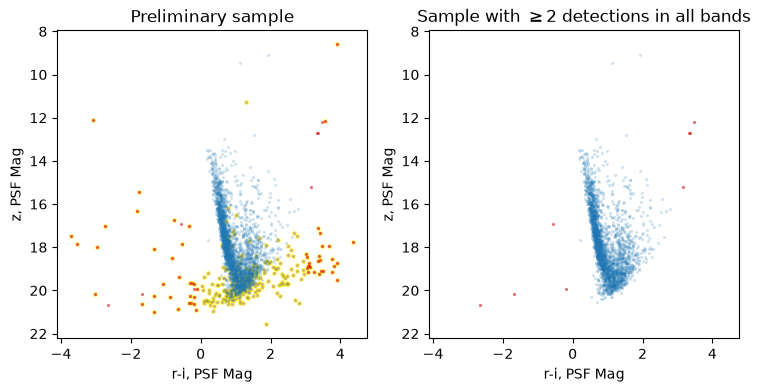

In [31]:
# Rough selection of suspect targets
f, axes = plt.subplots(1, 2)
f.set_size_inches((8.8, 4))

ax = axes[0]
ax.set_title("Preliminary sample")
ax.scatter(
    (sample['rmeanpsfmag']-sample['imeanpsfmag']),
    sample['zmeanpsfmag'], 
    s=5, lw=0, 
    alpha=0.2
)

ax.scatter(
    (sample['rmeanpsfmag']-sample['imeanpsfmag'])[whsuspect],
    sample['zmeanpsfmag'][whsuspect], 
    s=5, lw=0, 
    alpha=0.5,
    color='red'
)

ax.scatter(
    (sample['rmeanpsfmag']-sample['imeanpsfmag'])[~whmultdet],
    sample['zmeanpsfmag'][~whmultdet], 
    s=7, lw=1, 
    alpha=0.5,
    edgecolor='yellow', 
    zorder=-10
)


ax.set_xlabel("r-i, PSF Mag")
ax.set_ylabel("z, PSF Mag")

ax.set_ylim(ax.get_ylim()[::-1])

xlim = ax.get_xlim()
ylim = ax.get_ylim()


ax = axes[1]
ax.set_title(r"Sample with $\geq2$ detections in all bands")
ax.scatter(
    (sample['rmeanpsfmag']-sample['imeanpsfmag'])[whmultdet],
    sample['zmeanpsfmag'][whmultdet], 
    s=5, lw=0, 
    alpha=0.2
)

ax.scatter(
    (sample['rmeanpsfmag']-sample['imeanpsfmag'])[whmultdet & whsuspect],
    sample['zmeanpsfmag'][whmultdet & whsuspect], 
    s=5, lw=0, 
    alpha=0.5,
    color='red'
)


ax.set_xlabel("r-i, PSF Mag")
ax.set_ylabel("z, PSF Mag")

ax.set_xlim(xlim)
ax.set_ylim(ylim)

Many of our "color-outlier" suspect targets --- as well as some others we hadn't flagged --- are removed by requiring more than one detection in each relevant band!  The resulting sample is much closer to a clean color magnitude diagram.

These constraints are something that could have be applied as part of the initial query.

Further, similar checks can reveal whether an even more refined sample could be obtained by filtering on the information from the flags explored here, or if additional flags from, e.g., the individual detection catalog. This is left as an exercise for interested readers!

------------

## Additional Resources


### Astroquery.mast

- Access to MAST holdings, including catalogs, through the [Astropy-affiliated astroquery package](https://astroquery.readthedocs.io/en/latest/mast/mast.html).
- A full list of available MAST Astroquery catalog services is available through the [astroquery documentation](https://astroquery.readthedocs.io/en/latest/mast/mast_catalog.html).


### PanSTARRS 1 DR 2

- See the [PanSTARRS documentation](https://outerspace.stsci.edu/display/PANSTARRS/) for full details regarding PanSTARRS DR2 catalogs.

------------
## Citations
If you use `astropy` for published research, please cite the
authors. Follow these links for more information about citing `astropy`:

* [Citing `astropy`](https://www.astropy.org/acknowledging.html)

If you use PanSTARRS data accessed through MAST for published research, 
please include the following acknowledgements, found at the following links:

* [Acknowledging PanSTARRS](https://archive.stsci.edu/publishing/mission-acknowledgements#section-895d38a0-86b3-4143-b521-6cc3312701f9)
* [Acknowledging MAST](https://archive.stsci.edu/gsc/mast_data_use.html)

## About This Notebook

The use of MAST-Aladin in this notebook draws from the demonstrations in ["Intro to MastAladinLite" by Hatice Karatay](https://github.com/haticekaratay/roman_notebooks/blob/mast-aladin-demo/content/notebooks/data_visualization/Intro_To_Mast_Aladin_Lite.ipynb).


**Authors:** Sedona Price<br>
**Keywords:** Tutorial, astroquery, MAST-Aladin, bitflags<br>
**Last updated:** August 2026 <br>

***
[Top of Page](#top)
<img style="float: right;" src="https://raw.githubusercontent.com/spacetelescope/style-guides/master/guides/images/stsci-logo.png" alt="Space Telescope Logo" width="200px"/> 